In [1]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def process_sqlite_report_kernel_only(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()
    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id
    
    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [3]:
data_matrix = process_sqlite_report_kernel_only("build/Linux-x86_64/pool_matching_joint_matrix_fp16.sqlite")

In [4]:
data_normal_fp16 = process_sqlite_report_kernel_only("build_normal/Linux-x86_64/pool_matching_normal_fp16.sqlite")

In [5]:
data_normal_fp32 = process_sqlite_report_kernel_only("build_normal_fp32/Linux-x86_64/pool_matching_normal_fp32.sqlite")

In [6]:
data_matrix[13]

{'activity_type': 'kernel',
 'name': 'Typeinfo name for popsift::Compute_squared_norm',
 'start': 730683475,
 'end': 730686323,
 'duration': 2848,
 'registersPerThread': 16,
 'gridX': 1000,
 'gridY': 1,
 'gridZ': 1,
 'blockX': 32,
 'blockY': 1,
 'blockZ': 1,
 'staticSharedMemory': 0,
 'dynamicSharedMemory': 0,
 'localMemoryPerThread': 0,
 'localMemoryTotal': 42467328,
 'sharedMemoryLimitConfig': 0,
 'streamId': 32,
 'deviceId': 0,
 'bytes': None,
 'copyKind': None,
 'srcKind': None,
 'dstKind': None,
 'memKind': None}

In [7]:
len(data_matrix)

8762

In [8]:
len(data_normal_fp16)

2504

In [9]:
def tensor_replace_names(data):
    pattern = r'\blambda\b'
    for row in data:
        match = re.search(pattern, row["name"])
        if match: 
            row["name"] = "remainder_normal_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_distance_matrix_pre_norm":
            row["name"] = "matrix_matching"
        if row["name"] in ("Typeinfo name for popsift::Compute_squared_norm", "Typeinfo name for popsift::Compute_squared_norm_fp16_transform"):
            row["name"] = "compute_squared_norm"        

In [10]:
tensor_replace_names(data_matrix)

In [11]:
data_matrix[0]["start"]


723911182

In [12]:
data_matrix[2]["end"]

724382446

In [13]:
(data_matrix[2]["end"] - data_matrix[0]["start"]) / 1000000

0.471264

In [92]:
def tensor_match_time(data, warmup=4):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            start = row["start"]
            current_frame = True
        else: 
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > warmup:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > warmup:
                        times.append(row["end"] - start)
    return times

In [15]:
def tensor_only_match_time(data):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            # start = row["start"]
            current_frame = True
        else: 
            if current_frame:
                start = row["start"]
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > 4:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > 4:
                        times.append(row["end"] - start)
    return times

In [94]:
def normal_match_time(data, warmup=0):
    times: list[int] = []
    for row in data:
        times.append(row["duration"])
    return times[warmup:]

In [17]:
times_matrix =  tensor_match_time(data_matrix)
times_normal = normal_match_time(data_normal_fp16)[4:]
len(times_normal)

2500

In [18]:
def diff(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] - b[i])
    return diff_list
    
def diff_percent(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(100 * (a[i] - b[i]) / b[i])
    return diff_list

def diff_mult(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] / b[i])
    return diff_list

def diff_log2(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(np.log2(a[i] / b[i]))
    return diff_list

def distance_arounc_zero(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append((a[i] - b[i])/min(a[i], b[i]))
    return diff_list

In [19]:
times_normal[2499]

1779888591

In [20]:
times_matrix[2499]

87714868

In [21]:
times_normal[2499] - times_matrix[2499]

1692173723

In [22]:
diff_list = diff(times_normal, times_matrix)
diff_list_p = diff_percent(times_normal, times_matrix)
diff_list_mult = diff_mult(times_normal, times_matrix)

In [23]:
len(diff_list)

2500

In [24]:
data_normal = data_normal_fp16[4:]
len(data_normal)

2500

In [25]:
len(times_matrix)

2500

In [26]:
!pwd

/home/jorgen/personal/thesis/sycl_popsift


In [27]:
times_matrix[:5]

[519009, 973057, 1448545, 1914369, 2389857]

In [28]:
times_normal[:5]

[783461, 1546826, 2831283, 3581657, 3856218]

In [29]:
diff_list_mult[-5:]

[20.57715436764167,
 20.282568876288742,
 20.591241361868175,
 20.570584448608134,
 20.29175476841623]

In [30]:
tensor_meta = pd.read_csv("build/Linux-x86_64/matching_tensor_fp16_metadata.csv")
normal_meta = pd.read_csv("build_normal/Linux-x86_64/matching_normal_fp16_metadata.csv")
normal_fp32_meta = pd.read_csv("build_normal_fp32/Linux-x86_64/matching_normal_fp32_metadata.csv")

In [31]:
print(normal_meta.iloc[0])
print(normal_meta.iloc[0]['matches'])

l_desc_size    2000
r_desc_size    2000
matches         197
Name: 0, dtype: int64
197


In [32]:
def listify(data):
    l = tensor_meta["l_desc_size"].tolist()[4:]
    r = tensor_meta["r_desc_size"].tolist()[4:]
    return l, r

In [33]:
left_desc_len, right_desc_len = listify(tensor_meta)

In [34]:
len(left_desc_len)

2500

In [35]:
from scipy.interpolate import griddata

X, Y = np.meshgrid(left_desc_len, right_desc_len)

# Interpolate Z values onto the grid
ms_diff_list = [elm/1000000 for elm in diff_list] # from ns to ms
# diff_list_mult = [elm/100 for elm in diff_list_p]

Z = griddata((left_desc_len, right_desc_len), diff_list_mult, (X, Y), method='linear')

from scipy.ndimage import gaussian_filter

Z_smooth = gaussian_filter(Z, sigma=1)  # Adjust sigma as needed

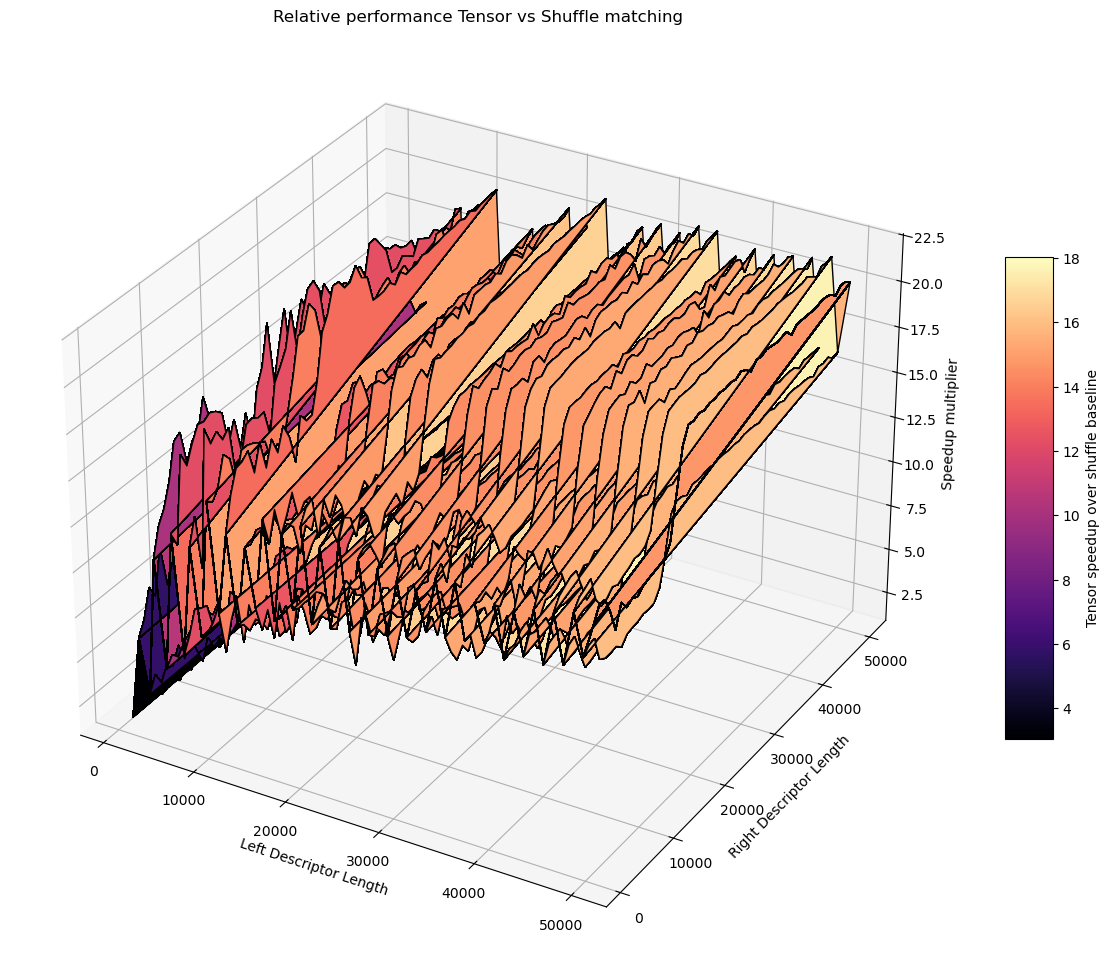

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='#000')
# surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='#333333')

# Labels
ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

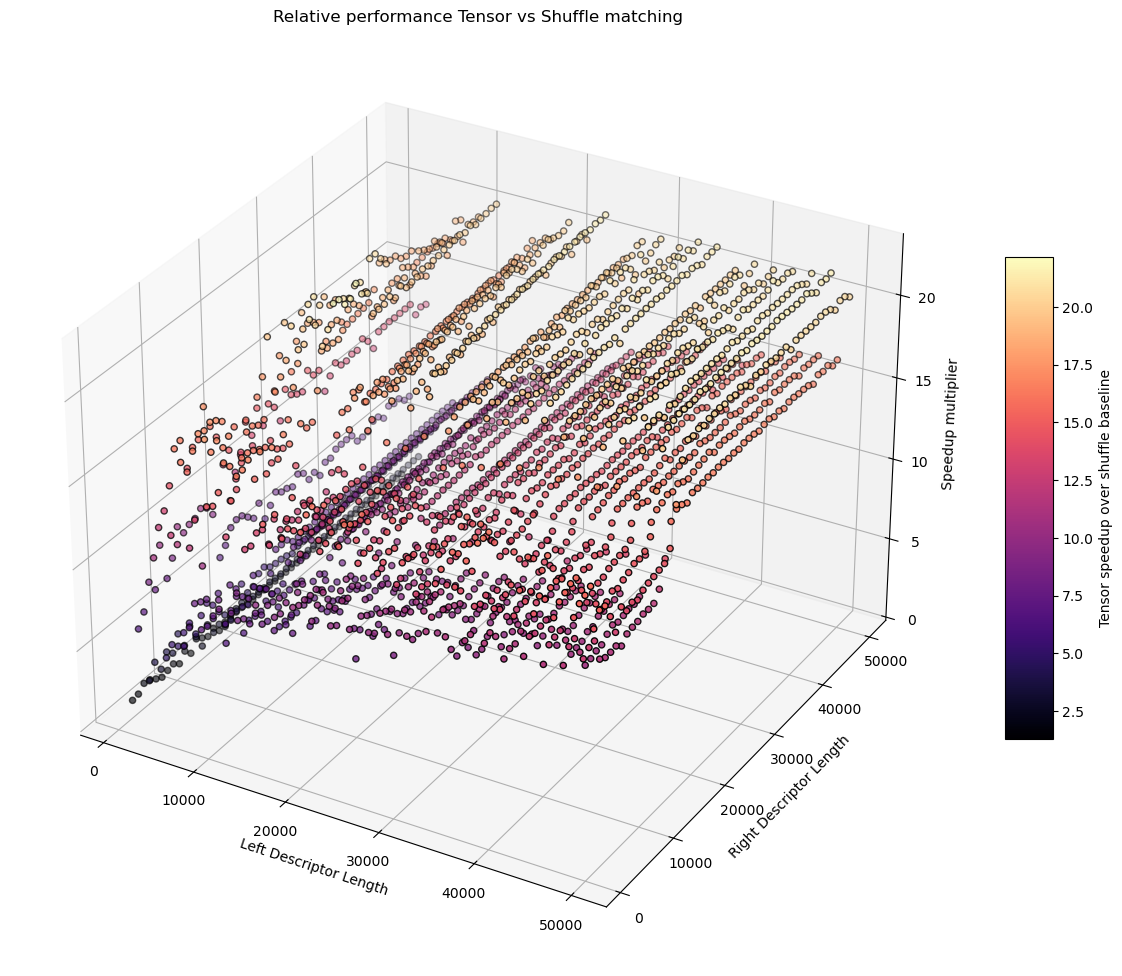

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(left_desc_len, right_desc_len, diff_list_mult,
           c=diff_list_mult, cmap='magma', edgecolor='k')


ax.set_title("Relative performance joint matrix vs collective sub-group matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Joint matrix speedup over collective sub-group baseline')
plt.tight_layout()
plt.show()

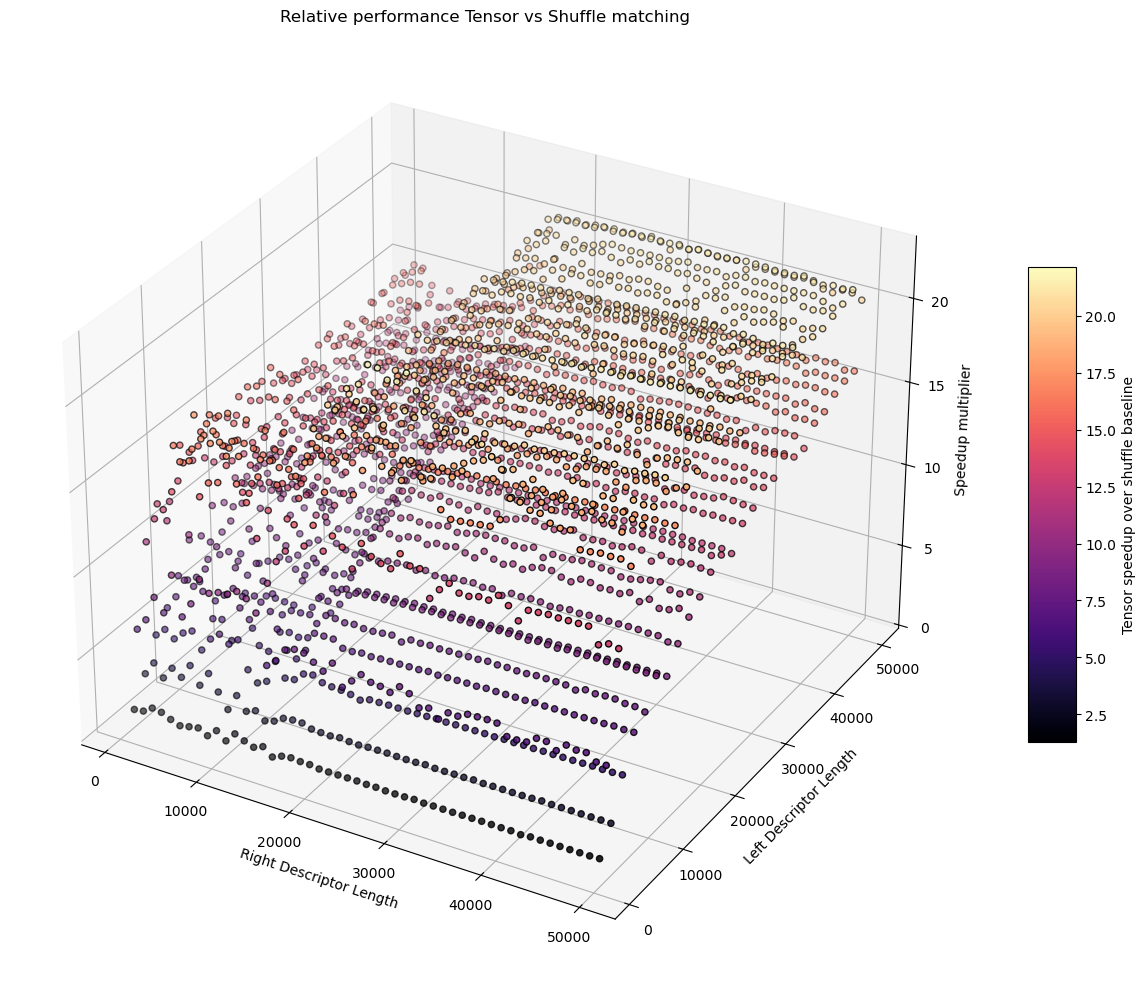

In [38]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(right_desc_len, left_desc_len, diff_list_mult,
           c=diff_list_mult, cmap='magma', edgecolor='k')

ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_ylabel("Left Descriptor Length")
ax.set_xlabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

In [39]:
len(diff_list_mult)

2500

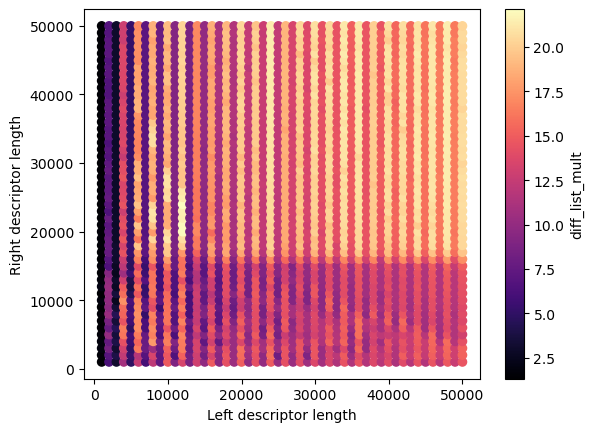

In [40]:

plt.scatter(left_desc_len, right_desc_len, c=diff_list_mult, cmap='magma')
plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='diff_list_mult')
plt.show()

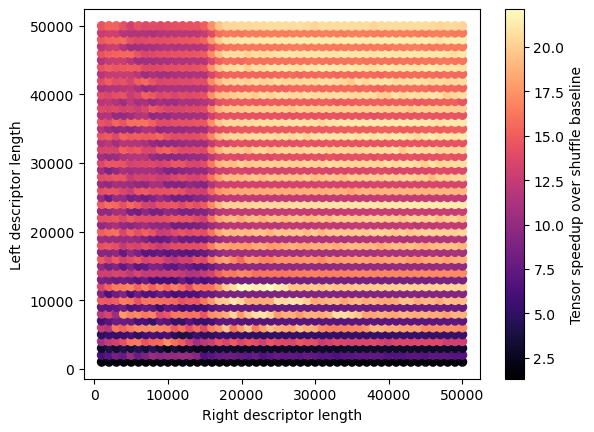

In [41]:

plt.scatter(right_desc_len,left_desc_len,  c=diff_list_mult, cmap='magma')
plt.ylabel('Left descriptor length')
plt.xlabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='Tensor speedup over shuffle baseline')
plt.show()

In [42]:
min(diff_list_mult)

1.3104040440652045

In [43]:
max(diff_list_mult)

22.14068151968851

In [44]:
############################# THE NEW SHIT WITH ZERO TAIL 

In [45]:
matrix_zero_tail = process_sqlite_report_kernel_only("build/Linux-x86_64/fp32_norm_fp16_matrix_match.sqlite")
tensor_replace_names(matrix_zero_tail)

In [46]:

times_matrix_zero =  tensor_match_time(matrix_zero_tail)

zero_over_normal = diff_mult(times_normal, times_matrix_zero)

In [47]:
X_zero, Y_zero = np.meshgrid(left_desc_len, right_desc_len)

# Interpolate Z values onto the grid
# ms_diff_list = [elm/1000000 for elm in diff_list] # from ns to ms
# diff_list_mult = [elm/100 for elm in diff_list_p]

Z_zero = griddata((left_desc_len, right_desc_len), zero_over_normal, (X_zero, Y_zero), method='linear')

from scipy.ndimage import gaussian_filter

Z_smooth = gaussian_filter(Z, sigma=1)  # Adjust sigma as needed

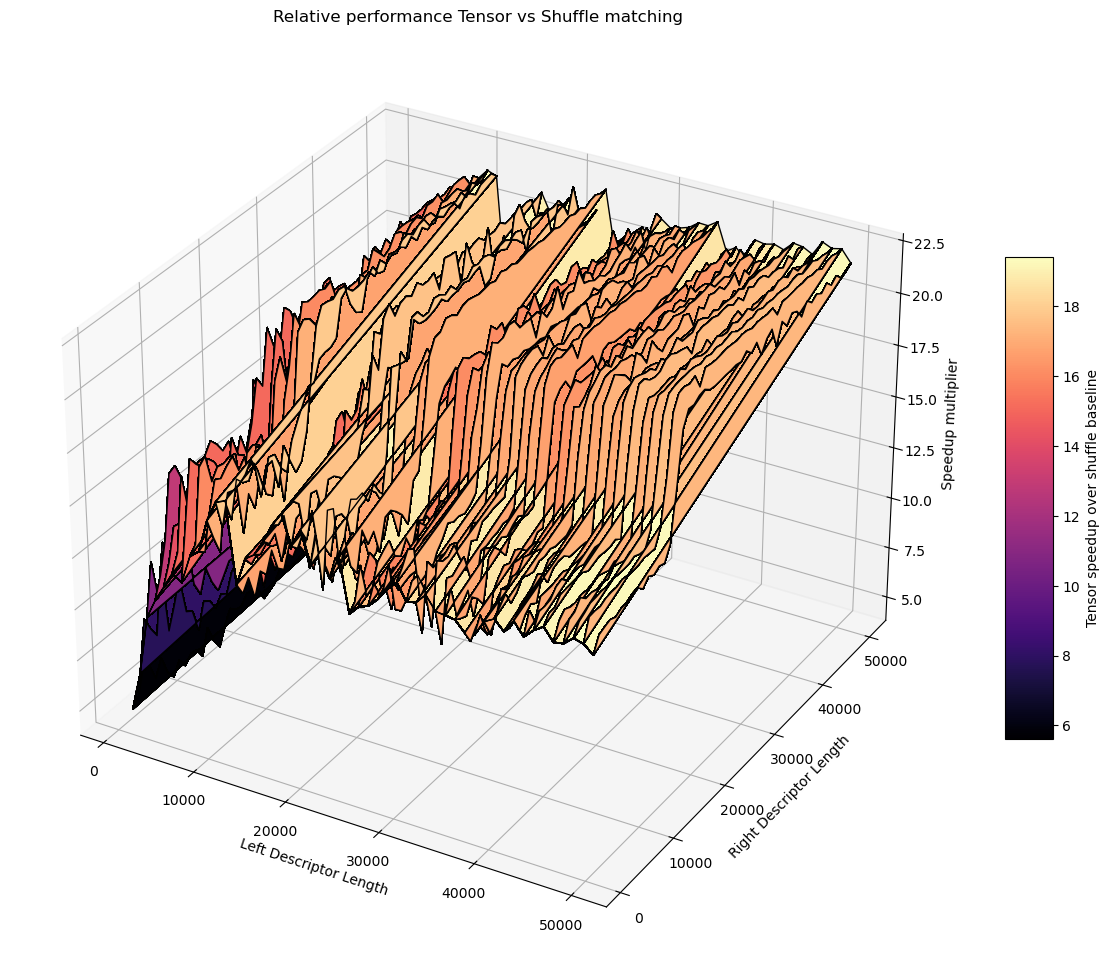

In [48]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(X_zero, Y_zero, Z_zero, cmap='magma', edgecolor='#000')
# surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='#333333')

# Labels
ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

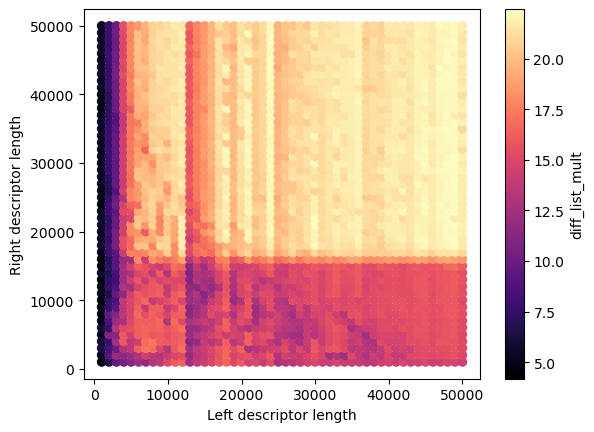

In [49]:
plt.scatter(left_desc_len, right_desc_len, c=zero_over_normal, cmap='magma')
plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='diff_list_mult')
plt.show()

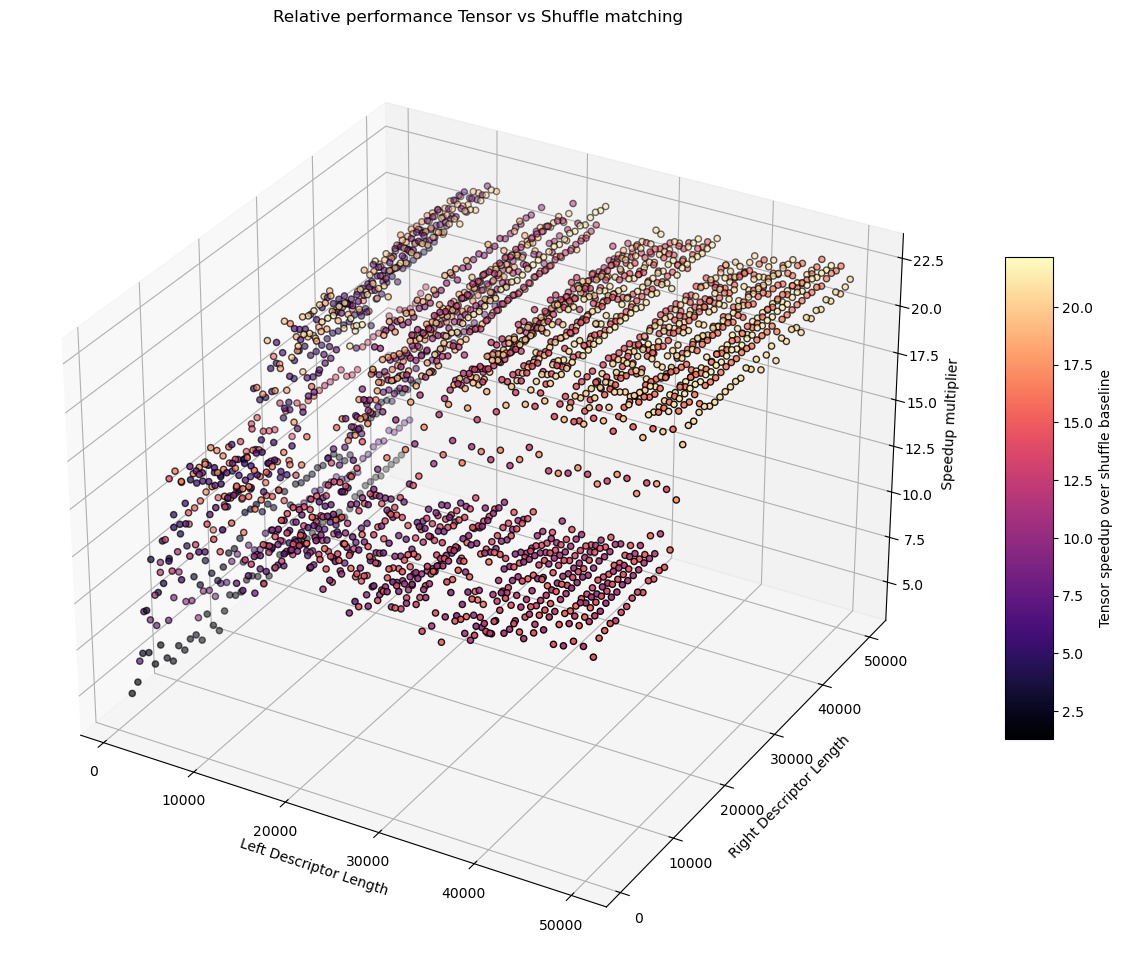

In [50]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(left_desc_len, right_desc_len, zero_over_normal,
           c=diff_list_mult, cmap='magma', edgecolor='k')


ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

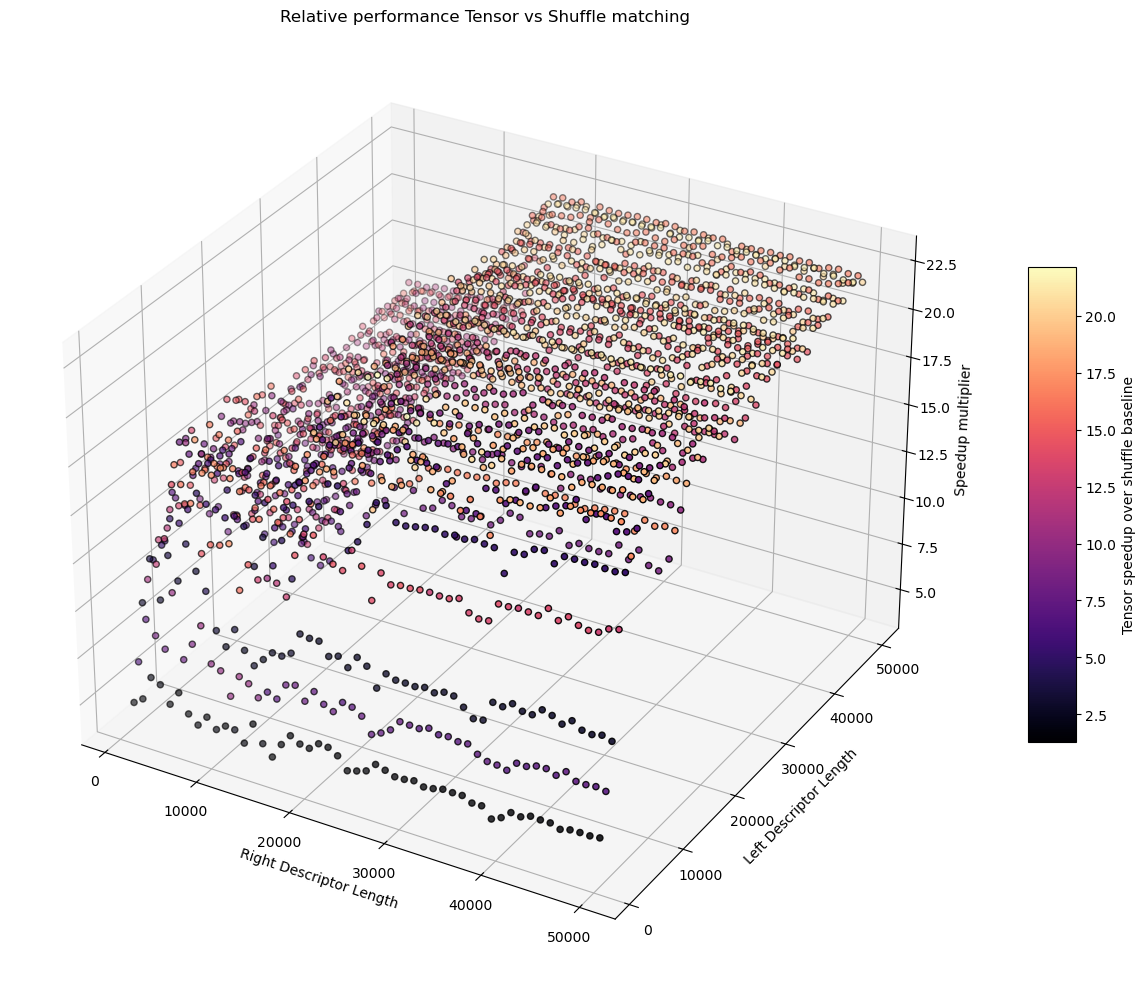

In [51]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(right_desc_len, left_desc_len, zero_over_normal,
           c=diff_list_mult, cmap='magma', edgecolor='k')

ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_ylabel("Left Descriptor Length")
ax.set_xlabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

In [52]:
################### COMPARE MATRIX TO MATRIX (normal tail vs zero tail)

In [53]:
def get_match_only(data):
    """ONLY FOR zero tail"""
    count = 0
    times = []
    for row in data:
        if row["name"] ==  "matrix_matching":
            count += 1
            if count > 4:
                # From 5'th frame 
                times.append(row["duration"])
    return times

def get_match_only_normal_tail(data):
    count = 0
    times = []
    for idx in range(len(data)):
        if data[idx]["name"] ==  "matrix_matching":
            count += 1
            if count > 4:
                # From 5'th frame 
                if idx == len(data) - 1:
                    # Last
                    times.append(data[idx]["duration"])
                else:
                    if data[idx + 1]["name"] == "remainder_normal_matching":
                        times.append(data[idx + 1]["end"] - data[idx]["start"])
                    else:
                        times.append(data[idx]["duration"])
    return times
        

In [54]:
# data_matrix[50:55]

In [55]:
zero_over_matrix = diff_log2(times_matrix, times_matrix_zero)
zero_over_matrix_linear = distance_arounc_zero(times_matrix, times_matrix_zero)


# Only match not squared norm kernel:
time_only_match_matrix = get_match_only_normal_tail(data_matrix)
time_zero_matrix_only_match = get_match_only(matrix_zero_tail)
zero_over_matrix_linear_match_only = distance_arounc_zero(time_only_match_matrix, time_zero_matrix_only_match)

In [56]:
time_only_match_matrix[:5]

[489057, 939521, 1412065, 1872449, 2345857]

In [57]:
time_only_match_matrix[:5]

[489057, 939521, 1412065, 1872449, 2345857]

In [58]:
time_zero_matrix_only_match[:5]

[137505, 272418, 408546, 542435, 685412]

In [59]:
len(time_only_match_matrix)

2500

In [60]:
times_matrix_zero[:5]

[165217, 303746, 442594, 580580, 731012]

In [61]:
matrix_zero_tail[14]

{'activity_type': 'kernel',
 'name': 'matrix_matching',
 'start': 1197435060,
 'end': 1197572565,
 'duration': 137505,
 'registersPerThread': 47,
 'gridX': 63,
 'gridY': 1,
 'gridZ': 1,
 'blockX': 32,
 'blockY': 1,
 'blockZ': 1,
 'staticSharedMemory': 0,
 'dynamicSharedMemory': 1024,
 'localMemoryPerThread': 0,
 'localMemoryTotal': 42467328,
 'sharedMemoryLimitConfig': 0,
 'streamId': 35,
 'deviceId': 0,
 'bytes': None,
 'copyKind': None,
 'srcKind': None,
 'dstKind': None,
 'memKind': None}

In [62]:
times_matrix[-15:]

[62062871,
 63587227,
 66721698,
 67371107,
 69120904,
 70915564,
 72628142,
 74317363,
 75761175,
 77494907,
 79685761,
 82602919,
 83033000,
 84899629,
 87714868]

In [63]:
times_matrix_zero[-15:]

[58561927,
 61307036,
 61918753,
 63827407,
 67038700,
 67035436,
 69530303,
 70497318,
 72818840,
 73497310,
 76206483,
 76988824,
 79750510,
 80957495,
 81849279]

In [64]:
min(zero_over_matrix)

np.float64(-0.643597048839821)

In [65]:
max(zero_over_matrix)

np.float64(2.101779756298328)

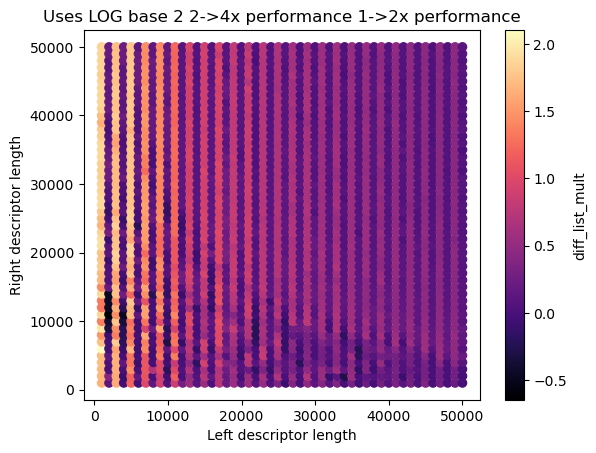

In [66]:
plt.scatter(left_desc_len, right_desc_len, c=zero_over_matrix, cmap='magma')
plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
plt.title('Uses LOG base 2 2->4x performance 1->2x performance')
plt.colorbar(label='diff_list_mult')
plt.show()

In [67]:
######### LINAR METRIC

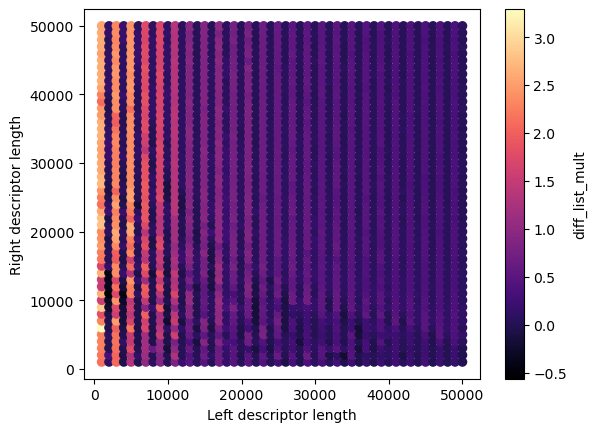

In [70]:
import matplotlib.colors as mcolors

vmin = np.min(zero_over_matrix_linear)
vmax = np.max(zero_over_matrix_linear)
abs_max = max(abs(vmin), abs(vmax))
norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

plt.scatter(left_desc_len, right_desc_len, c=zero_over_matrix_linear, cmap='magma')

plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='diff_list_mult')
plt.show()

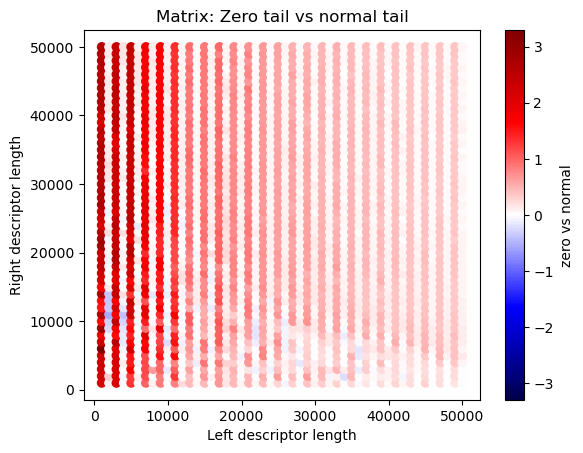

In [71]:
import matplotlib.colors as mcolors

vmin = np.min(zero_over_matrix_linear)
vmax = np.max(zero_over_matrix_linear)

# Make color scale symmetric around 0
abs_max = max(abs(vmin), abs(vmax))
norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

plt.scatter(
    left_desc_len, right_desc_len,
    c=zero_over_matrix_linear,
    cmap='seismic',  # you can also try 'coolwarm' or 'seismic' for diverging
    norm=norm
)

plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
plt.title("Matrix: Zero tail vs normal tail")
plt.colorbar(label='zero vs normal')
plt.show()

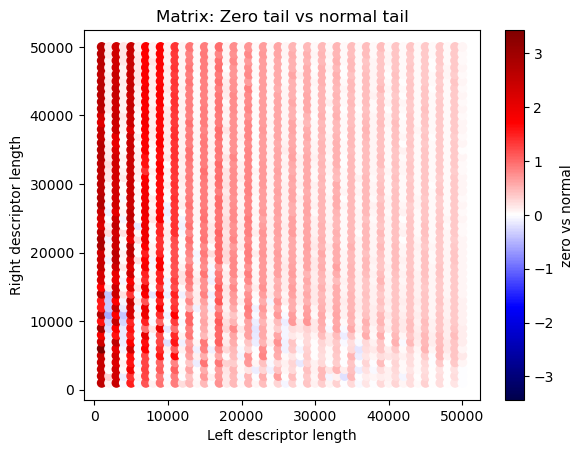

In [72]:
### USING THE MATCH ONLY AND NOT THE KERNLE TO COMPUTE NORMALIZED NORM

vmin = np.min(zero_over_matrix_linear_match_only)
vmax = np.max(zero_over_matrix_linear_match_only)

# Make color scale symmetric around 0
abs_max = max(abs(vmin), abs(vmax))
norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

plt.scatter(
    left_desc_len, right_desc_len,
    c=zero_over_matrix_linear_match_only,
    cmap='seismic',  # you can also try 'coolwarm' or 'seismic' for diverging
    norm=norm
)

plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
plt.title("Matrix: Zero tail vs normal tail")
plt.colorbar(label='zero vs normal')
plt.show()

In [73]:
min(zero_over_matrix_linear_match_only)

-0.5756162000752564

In [74]:
max(zero_over_matrix_linear_match_only)

3.4341279567896605

In [75]:
########### LEFT AND RIGHT SAME SO WE CAN DO 2D PLOT and statistical significance (which it's obvisoyly is)

In [84]:
matrix_lr_same = process_sqlite_report_kernel_only("build/Linux-x86_64/match_matrix_zero_tail_lr_same.sqlite")
tensor_replace_names(matrix_lr_same)
normal_lr_same = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_lr_same.sqlite")
cuda_normal_lr_same = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_lr_same.sqlite")

In [89]:
# Clean kernel names
tensor_replace_names(matrix_lr_same)

In [95]:
# Get times
times_matrix_lr_same =  tensor_match_time(matrix_lr_same, 10)
times_normal_lr_same = normal_match_time(normal_lr_same, 10)
times_cuda_normal_lr_same = normal_match_time(cuda_normal_lr_same, 10)

In [109]:
# Load metadata
tensor_meta_lr = pd.read_csv("build/Linux-x86_64/match_matrix_zero_tail_lr_same.csv")
normal_meta_lr = pd.read_csv("build/Linux-x86_64/match_normal_lr_same.csv")
cuda_normal_meta_lr = pd.read_csv("../popsift/build/Linux-x86_64/cuda_normal_lr_same.csv")

## They are all the same for dimensions

desc_len = []
for index, row in tensor_meta_lr.iterrows():
    desc_len.append(row['l_desc_size'])

desc_len = desc_len[10:]  # from 10'th frame

In [111]:
nvidia_color = "#76b900"
intel_color = "#00C7FD"
intel_color_dark = "#0068B5"

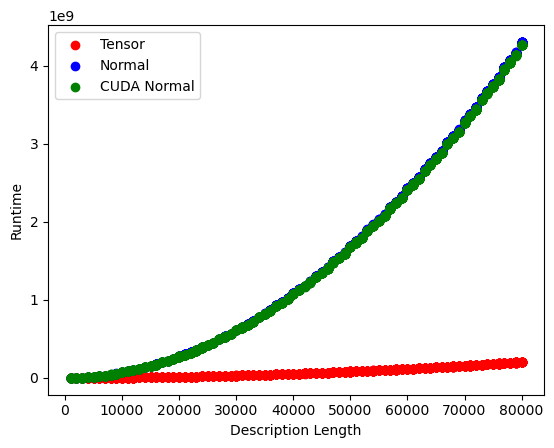

In [110]:
# Make scatterplot of tensor vs normal give with disticnt color and label in corner use make x be desc len (right and left are the same) make y runtime

import matplotlib.pyplot as plt


plt.scatter(desc_len, times_matrix_lr_same, color='r', label='Tensor')
plt.scatter(desc_len, times_normal_lr_same, color='b', label='Normal')
plt.scatter(desc_len, times_cuda_normal_lr_same, color='g', label='CUDA Normal')
plt.xlabel('Description Length')
plt.ylabel('Runtime')
plt.legend()
plt.show()

In [135]:
# There is only 80 datapoints and we have 20 repetitions for each. I would like to get the mean and stddev and visualize that in a scatter plot  with error bars for each point

# Make this computation use ms instad of ns
times_matrix_lr_same = [x / 1000000 for x in times_matrix_lr_same]
times_normal_lr_same = [x / 1000000 for x in times_normal_lr_same]
times_cuda_normal_lr_same = [x / 1000000 for x in times_cuda_normal_lr_same]
mean_tensor = []
std_tensor = []
mean_normal = []
std_normal = []
mean_cuda_normal = []
std_cuda_normal = []
# Warmup have been removed already
# the data for 1k is at idx 0, 80, 160, ...
for i in range(80):
    # Need an element at i, i+80, i+160, ..., i+1520
    tensor_vals = []
    normal_vals = []
    cuda_normal_vals = []
    for j in range(20):
        tensor_vals.append(times_matrix_lr_same[i + j*80])
        normal_vals.append(times_normal_lr_same[i + j*80])
        cuda_normal_vals.append(times_cuda_normal_lr_same[i + j*80])
    mean_tensor.append(np.mean(tensor_vals))
    std_tensor.append(np.std(tensor_vals))
    mean_normal.append(np.mean(normal_vals))
    std_normal.append(np.std(normal_vals))
    mean_cuda_normal.append(np.mean(cuda_normal_vals))
    std_cuda_normal.append(np.std(cuda_normal_vals))

# Print out the data:
for i in range(80):
    print(f"Desc Len: {desc_len[i]}, Tensor: {mean_tensor[i]:.2f} ± {std_tensor[i]:.2f}, Normal: {mean_normal[i]:.2f} ± {std_normal[i]:.2f}, CUDA Normal: {mean_cuda_normal[i]:.2f} ± {std_cuda_normal[i]:.2f}")    
    


Desc Len: 1000, Tensor: 0.18 ± 0.00, Normal: 0.73 ± 0.00, CUDA Normal: 0.73 ± 0.03
Desc Len: 2000, Tensor: 0.32 ± 0.01, Normal: 2.85 ± 0.25, CUDA Normal: 2.57 ± 0.10
Desc Len: 3000, Tensor: 0.49 ± 0.06, Normal: 4.61 ± 0.20, CUDA Normal: 4.83 ± 0.22
Desc Len: 4000, Tensor: 0.75 ± 0.08, Normal: 10.43 ± 0.59, CUDA Normal: 10.27 ± 0.47
Desc Len: 5000, Tensor: 1.03 ± 0.02, Normal: 14.66 ± 0.72, CUDA Normal: 14.73 ± 0.52
Desc Len: 6000, Tensor: 1.32 ± 0.02, Normal: 20.92 ± 0.57, CUDA Normal: 21.01 ± 1.07
Desc Len: 7000, Tensor: 1.89 ± 0.03, Normal: 29.29 ± 0.33, CUDA Normal: 29.12 ± 0.37
Desc Len: 8000, Tensor: 2.33 ± 0.01, Normal: 43.03 ± 0.32, CUDA Normal: 43.14 ± 0.71
Desc Len: 9000, Tensor: 3.30 ± 0.18, Normal: 56.59 ± 0.23, CUDA Normal: 56.19 ± 0.25
Desc Len: 10000, Tensor: 3.69 ± 0.02, Normal: 72.36 ± 0.50, CUDA Normal: 71.72 ± 0.52
Desc Len: 11000, Tensor: 4.49 ± 0.36, Normal: 84.87 ± 0.23, CUDA Normal: 84.29 ± 0.33
Desc Len: 12000, Tensor: 5.33 ± 0.36, Normal: 98.81 ± 0.33, CUDA Norm

In [136]:
x = [times_matrix_lr_same[x * 80] for x in range(20)]
# min(x) - max(x)
avg = sum(x) / len(x)
avg

0.17637799999999998

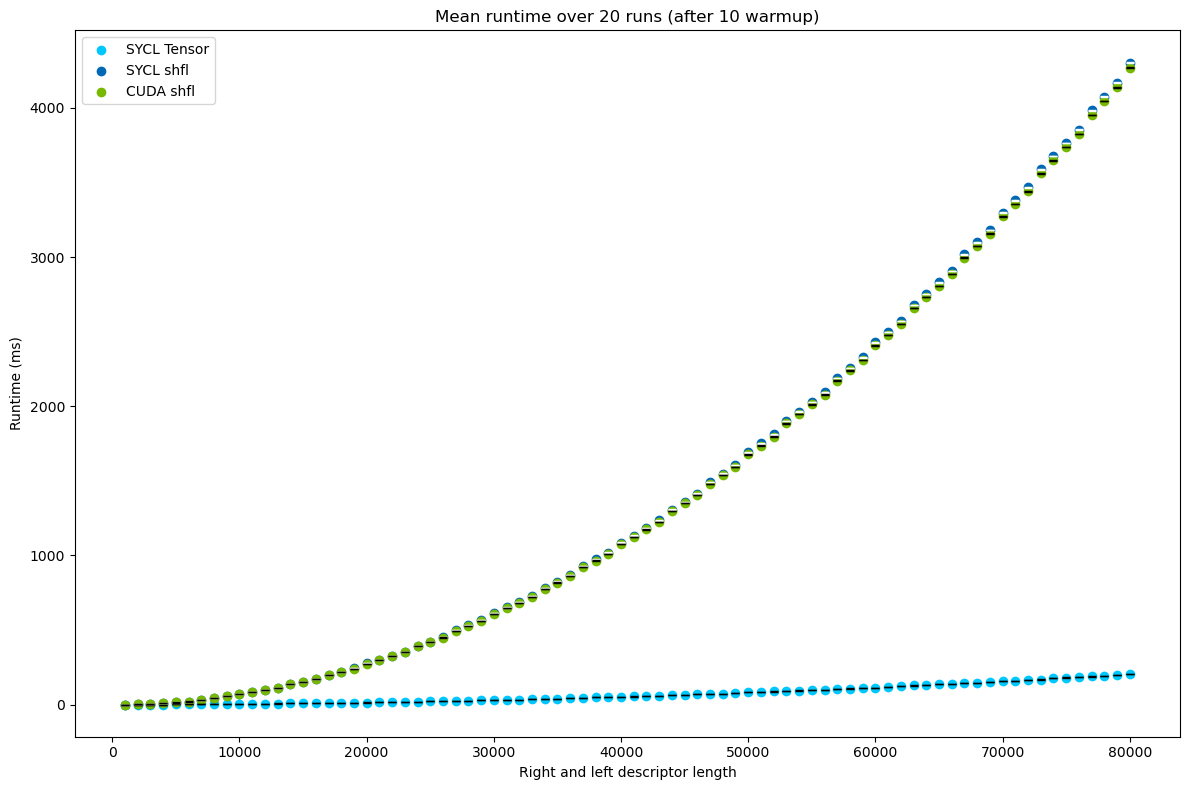

In [143]:
x = np.asarray(no_repeat_desc_len)

mt = np.asarray(mean_tensor)
mn = np.asarray(mean_normal)
mc = np.asarray(mean_cuda_normal)

st = np.asarray(std_tensor)
sn = np.asarray(std_normal)
sc = np.asarray(std_cuda_normal)

plt.figure(figsize=(12, 8))

# scatter points
plt.scatter(x, mt, label='SYCL Tensor', color=intel_color)
plt.scatter(x, mn, label='SYCL shfl', color=intel_color_dark)
plt.scatter(x, mc, label='CUDA shfl',  color=nvidia_color)

# error bars OVER the same x, y = means
# fmt='none' so we don't draw markers twice
plt.errorbar(x, mt, yerr=st, fmt='none', ecolor='black', elinewidth=1, capsize=3)
plt.errorbar(x, mn, yerr=sn, fmt='none', ecolor='white', elinewidth=1, capsize=3)
plt.errorbar(x, mc, yerr=sc, fmt='none', ecolor='black', elinewidth=1, capsize=3)

plt.xlabel('Right and left descriptor length')
plt.ylabel('Runtime (ms)')
plt.title('Mean runtime over 20 runs (after 10 warmup)')
plt.legend()
plt.tight_layout()
plt.show()

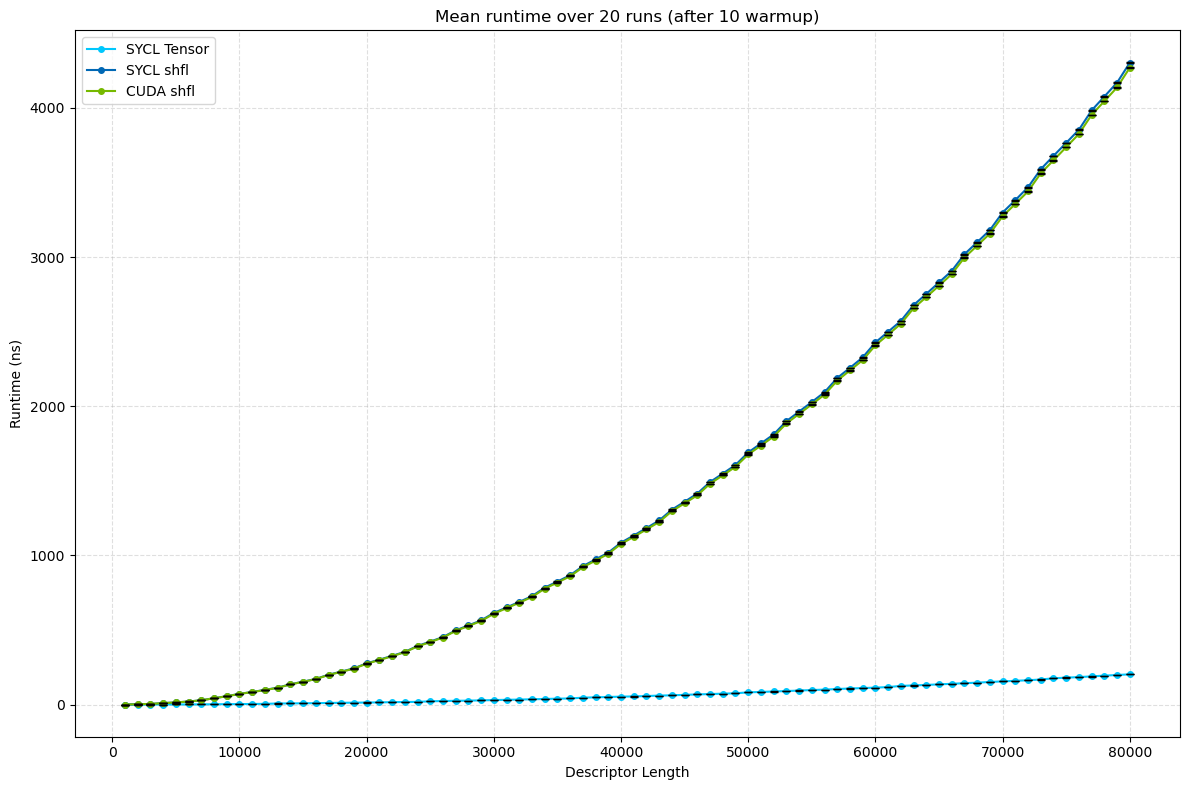

In [ ]:
x = np.asarray(no_repeat_desc_len)

mt = np.asarray(mean_tensor)
mn = np.asarray(mean_normal)
mc = np.asarray(mean_cuda_normal)

st = np.asarray(std_tensor)
sn = np.asarray(std_normal)
sc = np.asarray(std_cuda_normal)

plt.figure(figsize=(12, 8))

# Line plots for means with smaller dots
plt.plot(x, mt, label='SYCL Tensor', color=intel_color, marker='o', linestyle='-', markersize=4)
plt.plot(x, mn, label='SYCL shfl', color=intel_color_dark, marker='o', linestyle='-', markersize=4)
plt.plot(x, mc, label='CUDA shfl', color=nvidia_color, marker='o', linestyle='-', markersize=4)

# Black error bars (thinner and more subtle)
plt.errorbar(x, mt, yerr=st, fmt='none', ecolor='black', elinewidth=1, capsize=3)
plt.errorbar(x, mn, yerr=sn, fmt='none', ecolor='black', elinewidth=1, capsize=3)
plt.errorbar(x, mc, yerr=sc, fmt='none', ecolor='black', elinewidth=1, capsize=3)

plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ns)')
plt.title('Mean runtime over 20 runs (after 10 warmup)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
oplt.show()

/tmp/ipykernel_389539/3861859510.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


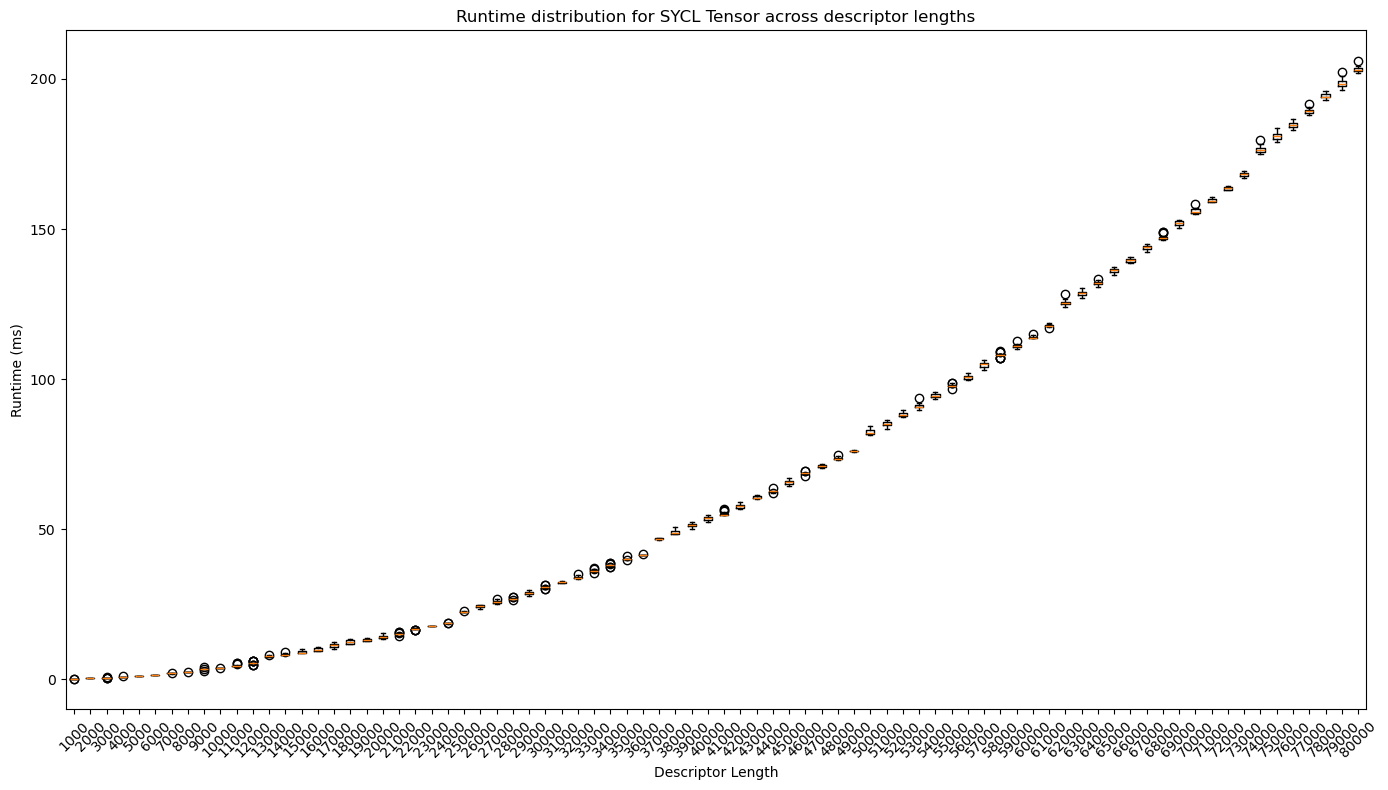

In [145]:
# Make box plots for each desc len for tensor
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
data_to_plot = []
labels = []
for i in range(80):
    # Need an element at i, i+80, i+160, ..., i+1520
    tensor_vals = []
    for j in range(20):
        tensor_vals.append(times_matrix_lr_same[i + j*80])
    data_to_plot.append(tensor_vals)
    labels.append(str(desc_len[i]))

plt.boxplot(data_to_plot, labels=labels)
plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ms)')
plt.title('Runtime distribution for SYCL Tensor across descriptor lengths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_389539/606608990.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


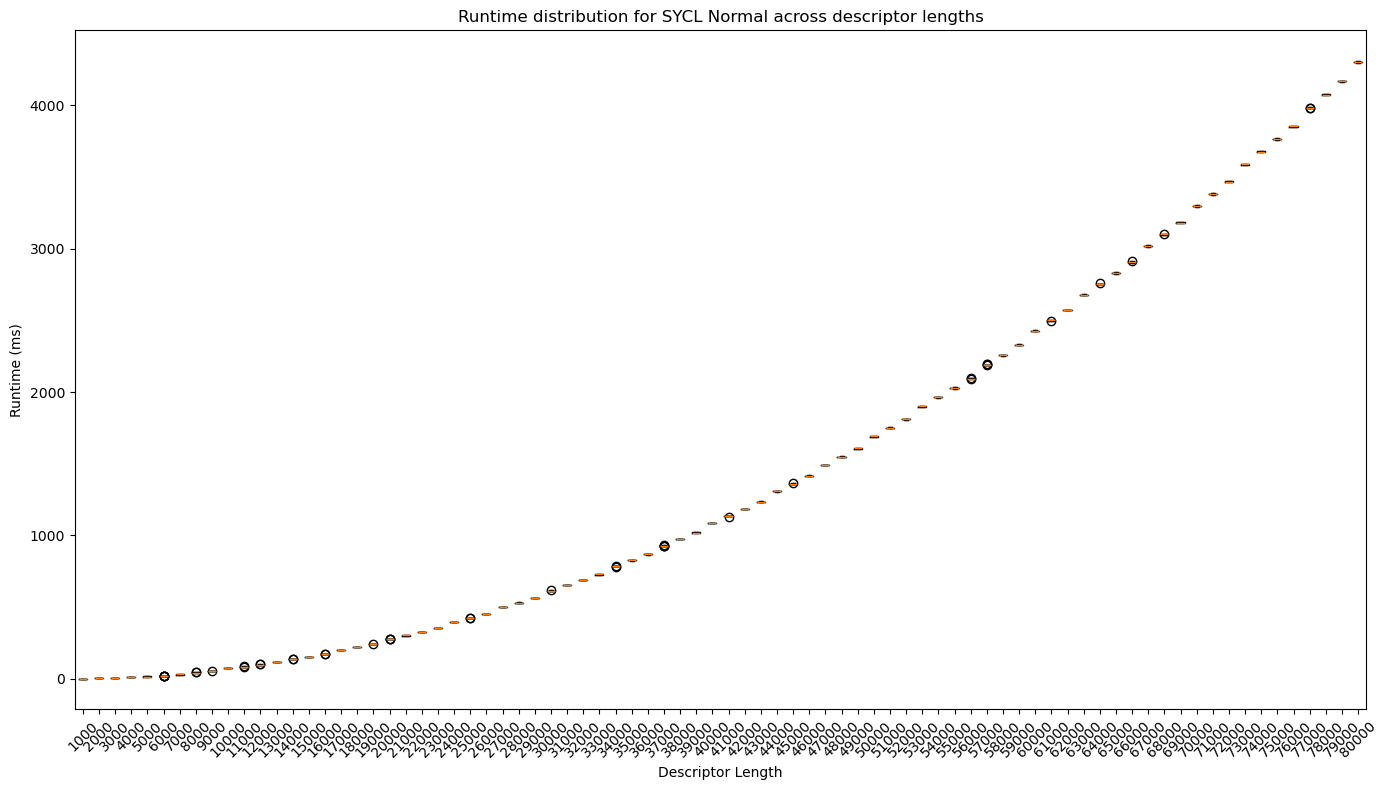

In [146]:
# make the same for normal
plt.figure(figsize=(14, 8))
data_to_plot = []
labels = []
for i in range(80):
    # Need an element at i, i+80, i+160, ..., i+1520
    normal_vals = []
    for j in range(20):
        normal_vals.append(times_normal_lr_same[i + j*80])
    data_to_plot.append(normal_vals)
    labels.append(str(desc_len[i]))

plt.boxplot(data_to_plot, labels=labels)
plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ms)')
plt.title('Runtime distribution for SYCL Normal across descriptor lengths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_389539/712264995.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


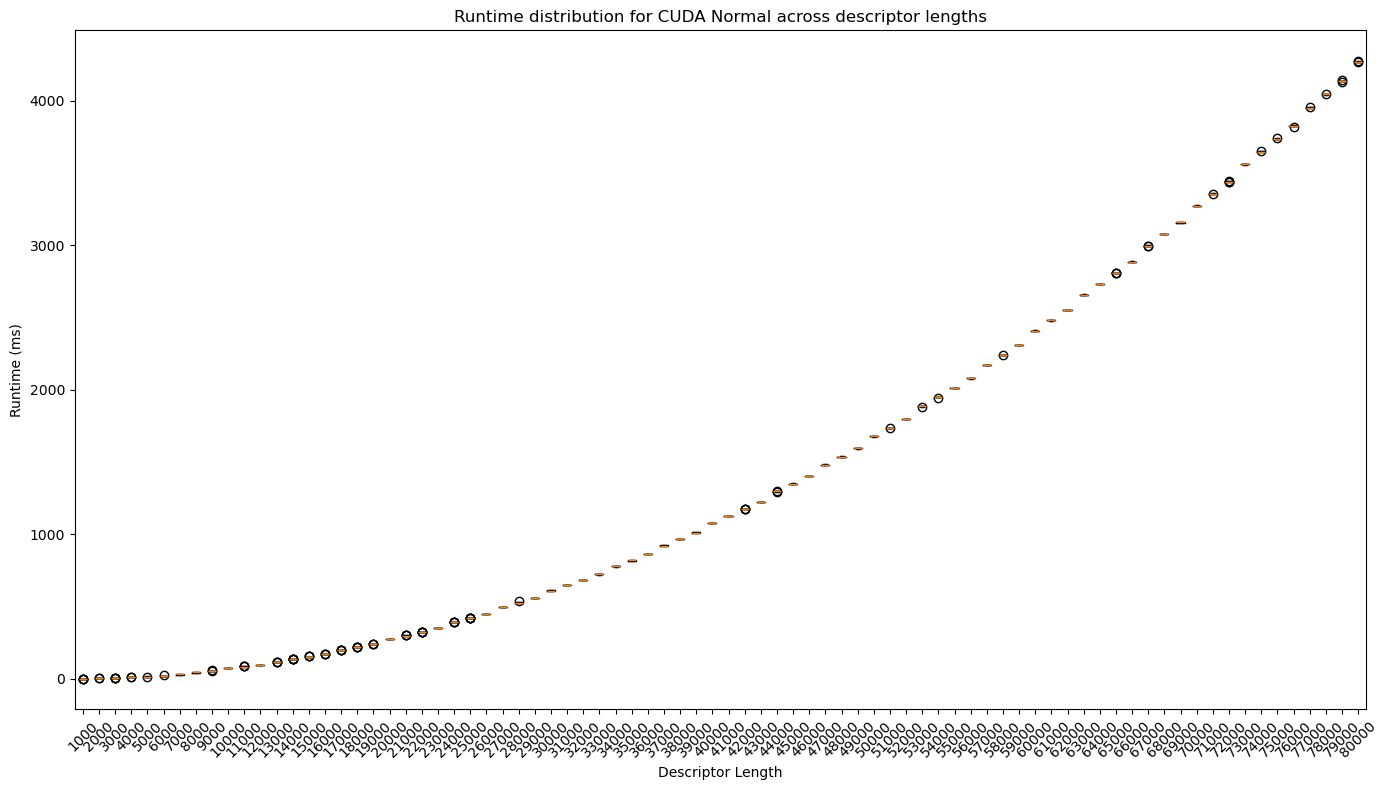

In [147]:
# Make the same for cuda normal but use nvidia_color for color
plt.figure(figsize=(14, 8))
data_to_plot = []
labels = []
for i in range(80):
    # Need an element at i, i+80, i+160, ..., i+1520
    cuda_normal_vals = []
    for j in range(20):
        cuda_normal_vals.append(times_cuda_normal_lr_same[i + j*80])
    data_to_plot.append(cuda_normal_vals)
    labels.append(str(desc_len[i]))

plt.boxplot(data_to_plot, labels=labels)
plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ms)')
plt.title('Runtime distribution for CUDA Normal across descriptor lengths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

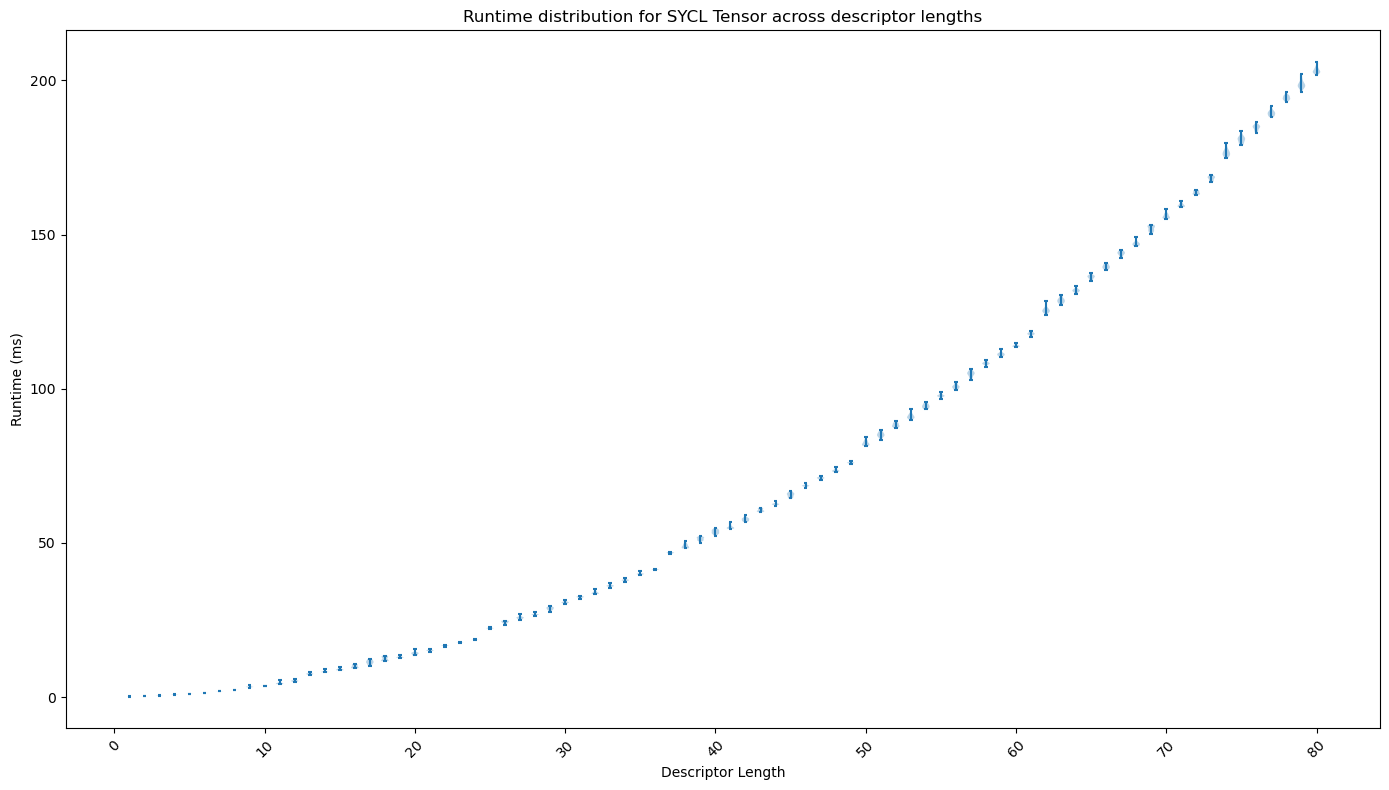

In [148]:
# Make violin plot for tensor
plt.figure(figsize=(14, 8))
data_to_plot = []
labels = []
for i in range(80):
    # Need an element at i, i+80, i+160, ..., i+1520
    tensor_vals = []
    for j in range(20):
        tensor_vals.append(times_matrix_lr_same[i + j*80])
    data_to_plot.append(tensor_vals)
    labels.append(str(desc_len[i]))

plt.violinplot(data_to_plot, showmeans=False)
plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ms)')
plt.title('Runtime distribution for SYCL Tensor across descriptor lengths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

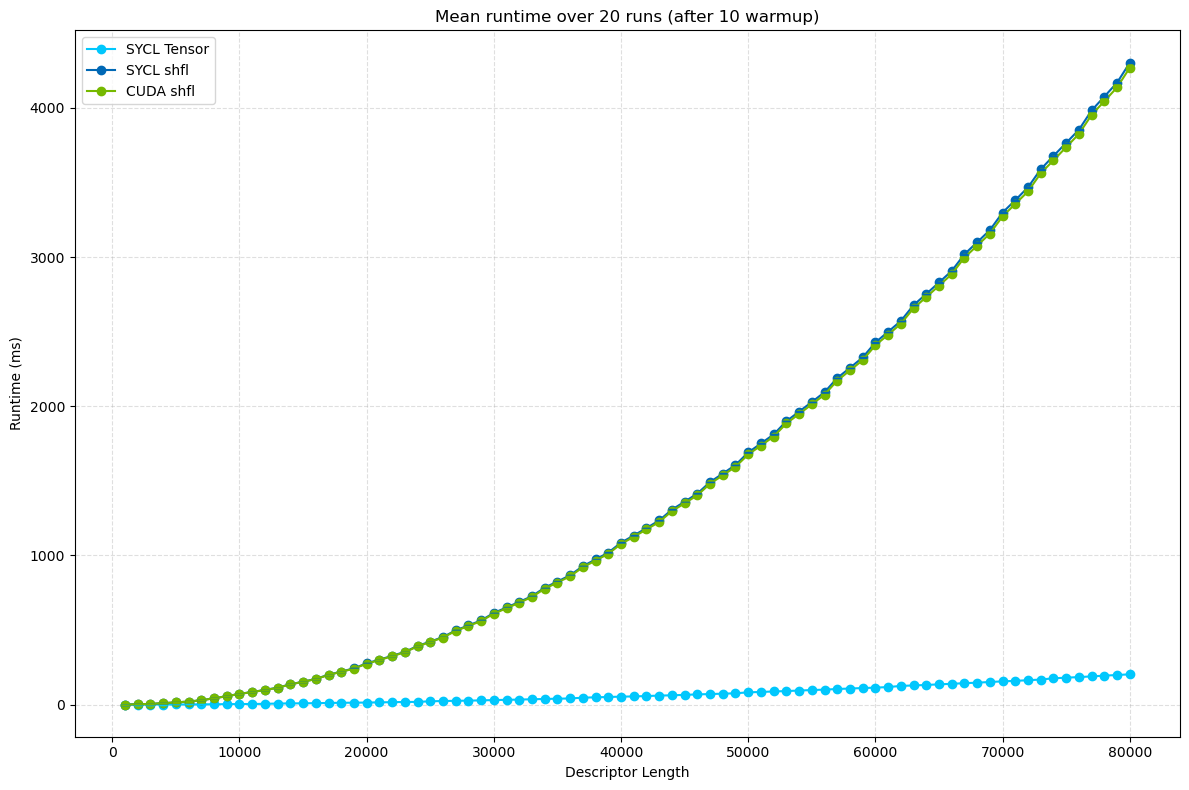

In [140]:

x = np.asarray(no_repeat_desc_len)

mt = np.asarray(mean_tensor)
mn = np.asarray(mean_normal)
mc = np.asarray(mean_cuda_normal)

st = np.asarray(std_tensor)
sn = np.asarray(std_normal)
sc = np.asarray(std_cuda_normal)

plt.figure(figsize=(12, 8))

# line plots for means
plt.plot(x, mt, label='SYCL Tensor', color=intel_color, marker='o', linestyle='-')
plt.plot(x, mn, label='SYCL shfl', color=intel_color_dark, marker='o', linestyle='-')
plt.plot(x, mc, label='CUDA shfl', color=nvidia_color, marker='o', linestyle='-')

# error bars for std
plt.errorbar(x, mt, yerr=st, fmt='none', ecolor=intel_color, elinewidth=1, capsize=3)
plt.errorbar(x, mn, yerr=sn, fmt='none', ecolor=intel_color_dark, elinewidth=1, capsize=3)
plt.errorbar(x, mc, yerr=sc, fmt='none', ecolor=nvidia_color, elinewidth=1, capsize=3)

plt.xlabel('Descriptor Length')
plt.ylabel('Runtime (ms)')
plt.title('Mean runtime over 20 runs (after 10 warmup)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [177]:
cases = []
run = []
method = []
for i in range(3):
    for j in range(20):
        for x in range(80):
            cases.append(x)
            run.append(j)
            if i == 0:
                method.append('SYCL_Tensor')
            elif i == 1:
                method.append('SYCL_Normal')
            else:
                method.append('CUDA_Normal')

In [ ]:
# FOR ANOVA
data = pd.DataFrame({
    'Case': cases,
    'Method': method,
    'Run': run,
    'Time': np.concatenate([times_matrix_lr_same,
                            times_normal_lr_same,
                            times_cuda_normal_lr_same])
})
data

,Case,Method,Run,Time
0,0,SYCL_Tensor,0,0.165888
1,1,SYCL_Tensor,0,0.310016
2,2,SYCL_Tensor,0,0.445889
3,3,SYCL_Tensor,0,0.700642
4,4,SYCL_Tensor,0,1.032418
...,...,...,...,...
4795,75,CUDA_Normal,19,3825.400413
4796,76,CUDA_Normal,19,3951.390025
4797,77,CUDA_Normal,19,4046.091794
4798,78,CUDA_Normal,19,4137.234739


In [180]:
print(data.shape)      # should be (4800, 4)
print(data.head(10))   # first few rows
data.groupby(['Case', 'Method']).size().head()

(4800, 4)
   Case       Method  Run      Time
0     0  SYCL_Tensor    0  0.165888
1     1  SYCL_Tensor    0  0.310016
2     2  SYCL_Tensor    0  0.445889
3     3  SYCL_Tensor    0  0.700642
4     4  SYCL_Tensor    0  1.032418
5     5  SYCL_Tensor    0  1.303330
6     6  SYCL_Tensor    0  1.902403
7     7  SYCL_Tensor    0  2.334308
8     8  SYCL_Tensor    0  2.802788
9     9  SYCL_Tensor    0  3.677830


Case  Method     
0     CUDA_Normal    20
      SYCL_Normal    20
      SYCL_Tensor    20
1     CUDA_Normal    20
      SYCL_Normal    20
dtype: int64

In [181]:
data_avg = data.groupby(['Case', 'Method'], as_index=False)['Time'].mean()
data_avg

,Case,Method,Time
0,0,CUDA_Normal,0.726855
1,0,SYCL_Normal,0.729695
2,0,SYCL_Tensor,0.176378
3,1,CUDA_Normal,2.569298
4,1,SYCL_Normal,2.848091
...,...,...,...
235,78,SYCL_Normal,4168.678201
236,78,SYCL_Tensor,198.676179
237,79,CUDA_Normal,4269.089858
238,79,SYCL_Normal,4302.211281


In [182]:
import pingouin as pg

anova_results = pg.rm_anova(
    dv='Time',
    within='Method',
    subject='Case',
    data=data_avg,
    detailed=True
)

print(anova_results)

   Source            SS   DF            MS           F         p-unc  \
0  Method  1.021471e+08    2  5.107355e+07  100.458515  7.069336e-29   
1   Error  8.032789e+07  158  5.084043e+05         NaN           NaN   

      p-GG-corr       ng2  eps sphericity       W-spher        p-spher  
0  9.961073e-16  0.277544  0.5      False  4.310421e-07  5.575313e-249  
1           NaN       NaN  NaN        NaN           NaN            NaN  


In [184]:
posthoc = pg.pairwise_tests(
    dv='Time',
    within='Method',
    subject='Case',
    data=data_avg,
    padjust='bonf',    # Bonferroni correction
    effsize='hedges'   # effect size type
)

print(posthoc[['A', 'B', 'T', 'p-corr', 'hedges']])

             A            B          T        p-corr    hedges
0  CUDA_Normal  SYCL_Normal -10.122756  1.916002e-15 -0.008597
1  CUDA_Normal  SYCL_Tensor  10.022448  2.994362e-15  1.500297
2  SYCL_Normal  SYCL_Tensor  10.023338  2.982513e-15  1.501026


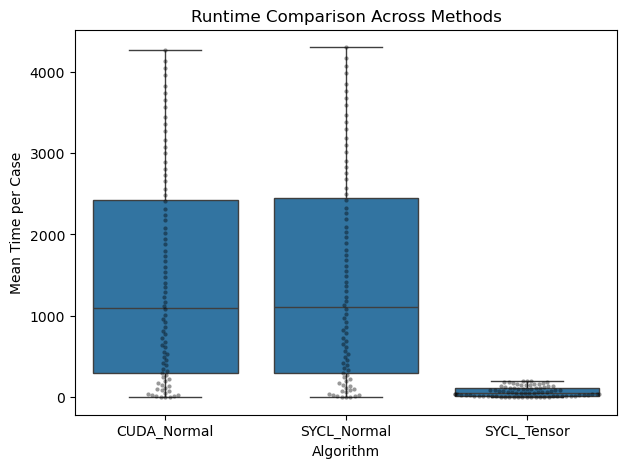

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(data=data_avg, x='Method', y='Time')
sns.swarmplot(data=data_avg, x='Method', y='Time', color='black', alpha=0.4, size=3)
plt.title('Runtime Comparison Across Methods')
plt.ylabel('Mean Time per Case')
plt.xlabel('Algorithm')
plt.show()

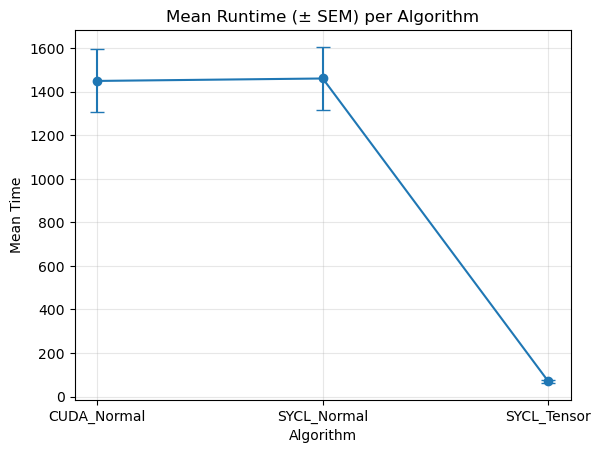

In [186]:
summary = data_avg.groupby('Method')['Time'].agg(['mean', 'sem']).reset_index()

plt.errorbar(summary['Method'], summary['mean'], yerr=summary['sem'], fmt='o-', capsize=5)
plt.title('Mean Runtime (± SEM) per Algorithm')
plt.ylabel('Mean Time')
plt.xlabel('Algorithm')
plt.grid(alpha=0.3)
plt.show()

In [189]:
data_avg.groupby('Method')['Time'].mean()

Method
CUDA_Normal    1448.613328
SYCL_Normal    1459.813063
SYCL_Tensor      70.318732
Name: Time, dtype: float64

In [194]:
# Subset only the two Normal methods
subset = data_avg[data_avg['Method'].isin(['CUDA_Normal', 'SYCL_Normal'])]

# # Pivot to wide format: one column per method
wide = subset.pivot(index='Case', columns='Method', values='Time')

# # Compute difference per case
wide['diff'] = wide['SYCL_Normal'] - wide['CUDA_Normal']

# wide.head()


wide

Method,CUDA_Normal,SYCL_Normal,diff
Case,,,
0,0.726855,0.729695,0.002840
1,2.569298,2.848091,0.278793
2,4.825345,4.607814,-0.217530
3,10.266642,10.431490,0.164849
4,14.729613,14.662600,-0.067012
...,...,...,...
75,3825.297080,3853.110370,27.813289
76,3952.909661,3982.776890,29.867230
77,4044.624230,4075.634680,31.010451


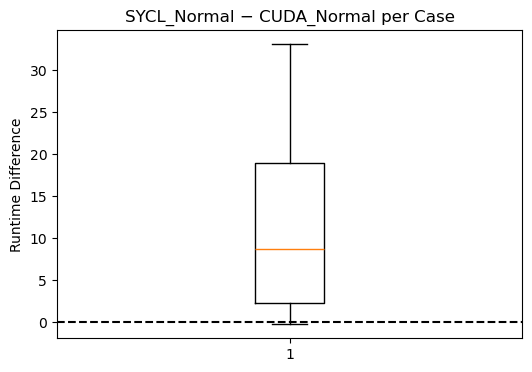

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(wide['diff'])
plt.axhline(0, color='black', linestyle='--')
plt.title('SYCL_Normal − CUDA_Normal per Case')
plt.ylabel('Runtime Difference')
plt.show()

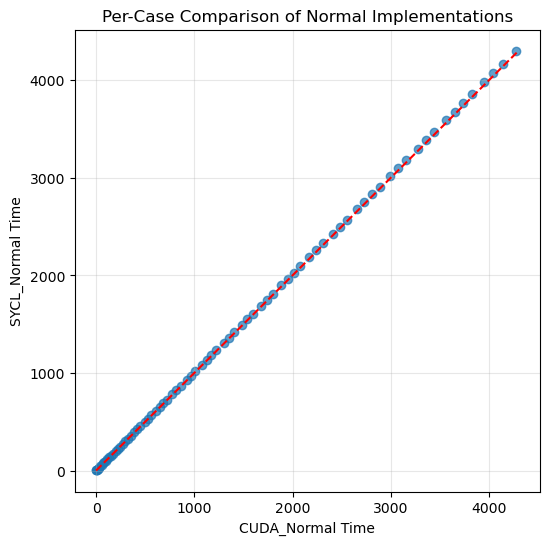

In [198]:
plt.figure(figsize=(6,6))
plt.scatter(wide['CUDA_Normal'], wide['SYCL_Normal'], alpha=0.7)
plt.plot([wide.min().min(), wide.max().max()],
         [wide.min().min(), wide.max().max()],
         color='red', linestyle='--')
         # SET y scale to log
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('CUDA_Normal Time')
plt.ylabel('SYCL_Normal Time')
plt.title('Per-Case Comparison of Normal Implementations')
plt.grid(True, alpha=0.3)
plt.show()

In [202]:
from scipy.stats import ttest_rel

p_values = []
for case in range(80):
    cuda = data[(data['Case']==case) & (data['Method']=='CUDA_Normal')]['Time']
    sycl = data[(data['Case']==case) & (data['Method']=='SYCL_Normal')]['Time']
    t, p = ttest_rel(sycl, cuda)
    p_values.append(p)

# See how many cases are significantly different
significant = sum(p < 0.05 for p in p_values)
print(f"{significant} out of 80 cases show a significant difference (p<0.05).")

p_values

for i, p in enumerate(p_values):
    print(f"p-value for case {i}: {p} --> Significant" if p < 0.05 else f"p-value for case {i}: {p} --> Not Significant")

74 out of 80 cases show a significant difference (p<0.05).
p-value for case 0: 0.7004979523197378 --> Not Significant
p-value for case 1: 0.00026383467182884544 --> Significant
p-value for case 2: 0.012147092733680654 --> Significant
p-value for case 3: 0.21501777716980483 --> Not Significant
p-value for case 4: 0.7227386192737597 --> Not Significant
p-value for case 5: 0.7932401635872245 --> Not Significant
p-value for case 6: 0.2479416699325864 --> Not Significant
p-value for case 7: 0.5211799856006696 --> Not Significant
p-value for case 8: 2.0041438199796002e-05 --> Significant
p-value for case 9: 0.000601976286593448 --> Significant
p-value for case 10: 1.0950895214300156e-05 --> Significant
p-value for case 11: 1.529055537282478e-09 --> Significant
p-value for case 12: 6.761935777147436e-07 --> Significant
p-value for case 13: 1.2092135619290728e-07 --> Significant
p-value for case 14: 9.885992438418075e-09 --> Significant
p-value for case 15: 8.907188858517428e-07 --> Significan